<a href="https://colab.research.google.com/github/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIM: To implement K-Means clustering on the Chronic Kidney Disease (CKD) dataset and analyze how data points are grouped into clusters.

THEORY:

K-Means is an unsupervised learning algorithm used to group data into K clusters based on similarity.

It assigns data points to clusters such that intra-cluster distance is minimized
Works iteratively:
Choose K centroids
Assign points to nearest centroid
Update centroids
Repeat until convergence

Unlike Decision Trees:

No labels required (unsupervised) and finds hidden patterns

Step 1 — Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

Step 2 — Load Dataset

In [5]:
url = "https://raw.githubusercontent.com/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/main/data/chronic_kidney_disease_full.csv"

df = pd.read_csv(url)
df.head()

,'age','bp','sg','al','su','rbc','pc','pcc','ba','bgr',...,'pcv','wbcc','rbcc','htn','dm','cad','appet','pe','ane','class'
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


Step 3 — Basic Preprocessing

In [6]:
df.columns = df.columns.str.strip().str.replace("'", "")

In [8]:
# Separate types
num_cols = df.select_dtypes(include=['float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Step 4 — Check data

In [9]:
df.isnull().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


Step 5 — Convert Categorical to Numeric

K-Means only understands numbers so we’ll encode them.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,32,72,34,1,4,1,0,1,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,26,56,34,0,3,1,0,1,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,19,70,34,0,4,1,2,1,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,20,62,19,1,3,1,2,2,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,23,68,27,0,3,1,0,1,0,0


Step 6 — Separate Features

In [11]:
X = df.drop('class', axis=1)

print("Shape of X:", X.shape)

Shape of X: (400, 24)


Step 7 — Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.21003135  0.25421378  0.4214856   0.07624929 -0.38026942  0.36488968
   0.4843221  -0.34251779 -0.24124895 -0.32012207 -0.41945149 -0.31966815
   0.04010412 -0.06290305  1.05322632  0.57539377  0.29320359  0.42484446
   1.3119026   1.2094158  -0.27668579 -0.51072333 -0.47269012 -0.42008403]
 [-2.62723421 -1.97247624  0.4214856   2.36372784 -0.38026942  0.36488968
   0.4843221  -0.34251779 -0.24124895 -0.32012207 -0.78431531 -0.39081916
   0.04010412 -0.06290305 -0.45796455 -0.14799284 -0.28632173  0.42484446
  -0.76225171 -0.51832106 -0.27668579 -0.51072333 -0.47269012 -0.42008403]
 [ 0.615355    0.25421378 -1.4210744   0.83874214  2.50785277  0.36488968
   0.4843221  -0.34251779 -0.24124895  3.69761778 -0.07485789 -0.21294164
   0.04010412 -0.06290305 -1.08455588 -0.99194389  0.22076293  0.42484446
  -0.76225171  1.2094158  -0.27668579  1.96551101 -0.47269012  2.38047614]
 [-0.21003135 -0.48801623 -2.3423544   2.36372784 -0.38026942  0.36488968
  -2.0647416   2.91955639 -0.241248

Step 8 — Elbow Method

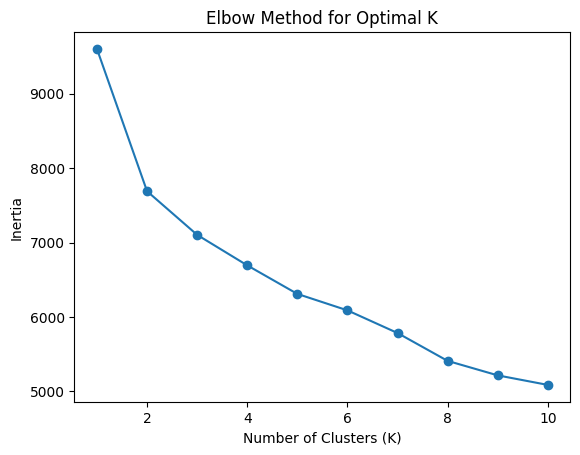

In [13]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

Big drop from K=1 to 2
Still decent drop at K=3
After that the curve starts flattening.

So the elbow is around:
K = 2 (best choice)

Step 9 — Train Final KMeans Model

In [14]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([1, 1, 0, 0, 1, 0, 0, 0, 0, 0], dtype=int32)

Step 10 — Add Cluster Labels to Dataset

In [15]:
df['cluster'] = clusters

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class,cluster
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,72,34,1,4,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,56,34,0,3,1,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,70,34,0,4,1,2,1,1,0,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,62,19,1,3,1,2,2,1,0,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,68,27,0,3,1,0,1,0,0,1


Step 11 — Compare with Actual Class

In [16]:
pd.crosstab(df['cluster'], df['class'])

class,0,1,2
cluster,,,
0,178,0,0
1,72,1,149


Step 12 — Fix Class Labels

In [17]:
df['class'] = df['class'].replace({2:1})

print(df['class'].value_counts())

class
0    250
1    150
Name: count, dtype: int64


Step 13 — Recheck Cluster vs Class

In [18]:
pd.crosstab(df['cluster'], df['class'])

class,0,1
cluster,,
0,178,0
1,72,150


Step 14 — Visualization

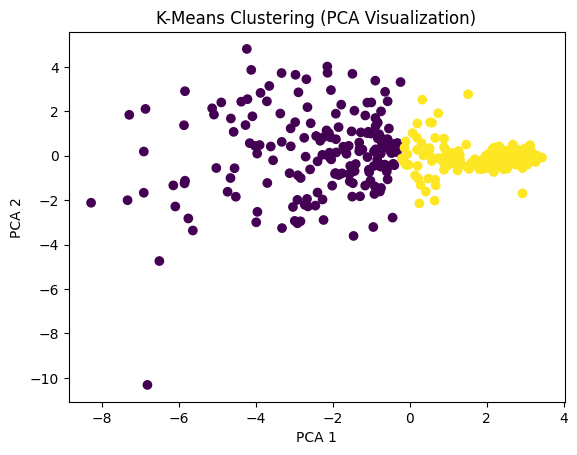

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Conclusion

In this experiment, K-Means clustering was applied to the Chronic Kidney Disease dataset after appropriate preprocessing and feature scaling. The optimal number of clusters was determined using the Elbow Method, which suggested K = 2.

The clustering results showed that the algorithm was able to effectively group patients into two clusters that largely correspond to CKD and non-CKD classes. Although K-Means is an unsupervised learning algorithm and does not use class labels during training, it still identified meaningful patterns in the data.

Thus, K-Means proves to be useful for discovering hidden structures in medical datasets, though it may not achieve perfect classification accuracy.